In [19]:
import itertools
import os
import shutil
from pathlib import Path
from typing import List

import autorootcwd
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from natsort import natsorted
from PIL import Image
from tqdm import tqdm

In [20]:
FIGURES_DIR = Path("figures")
WORKDIR_DIR = Path("workdir")
DEFAULT_MODELS = ["Unet", "SwinUNETR", "CSNet", "FRUnet"]


def _get_workdir_path(dataset: str, model: str, sampling_method: str = "") -> Path:
    """작업 디렉토리 경로 생성 로직 단일화"""
    dir_name = f"{sampling_method}/{dataset}-{model}" if sampling_method else f"{dataset}-{model}"
    return WORKDIR_DIR / dir_name

Searching in workdir/flow/OCTA500_6M-Unet/results-100000
Searching in workdir/flow/OCTA500_6M-SwinUNETR/results-100000
Searching in workdir/flow/OCTA500_6M-CSNet/results-100000
Searching in workdir/flow/OCTA500_6M-FRUnet/results-100000


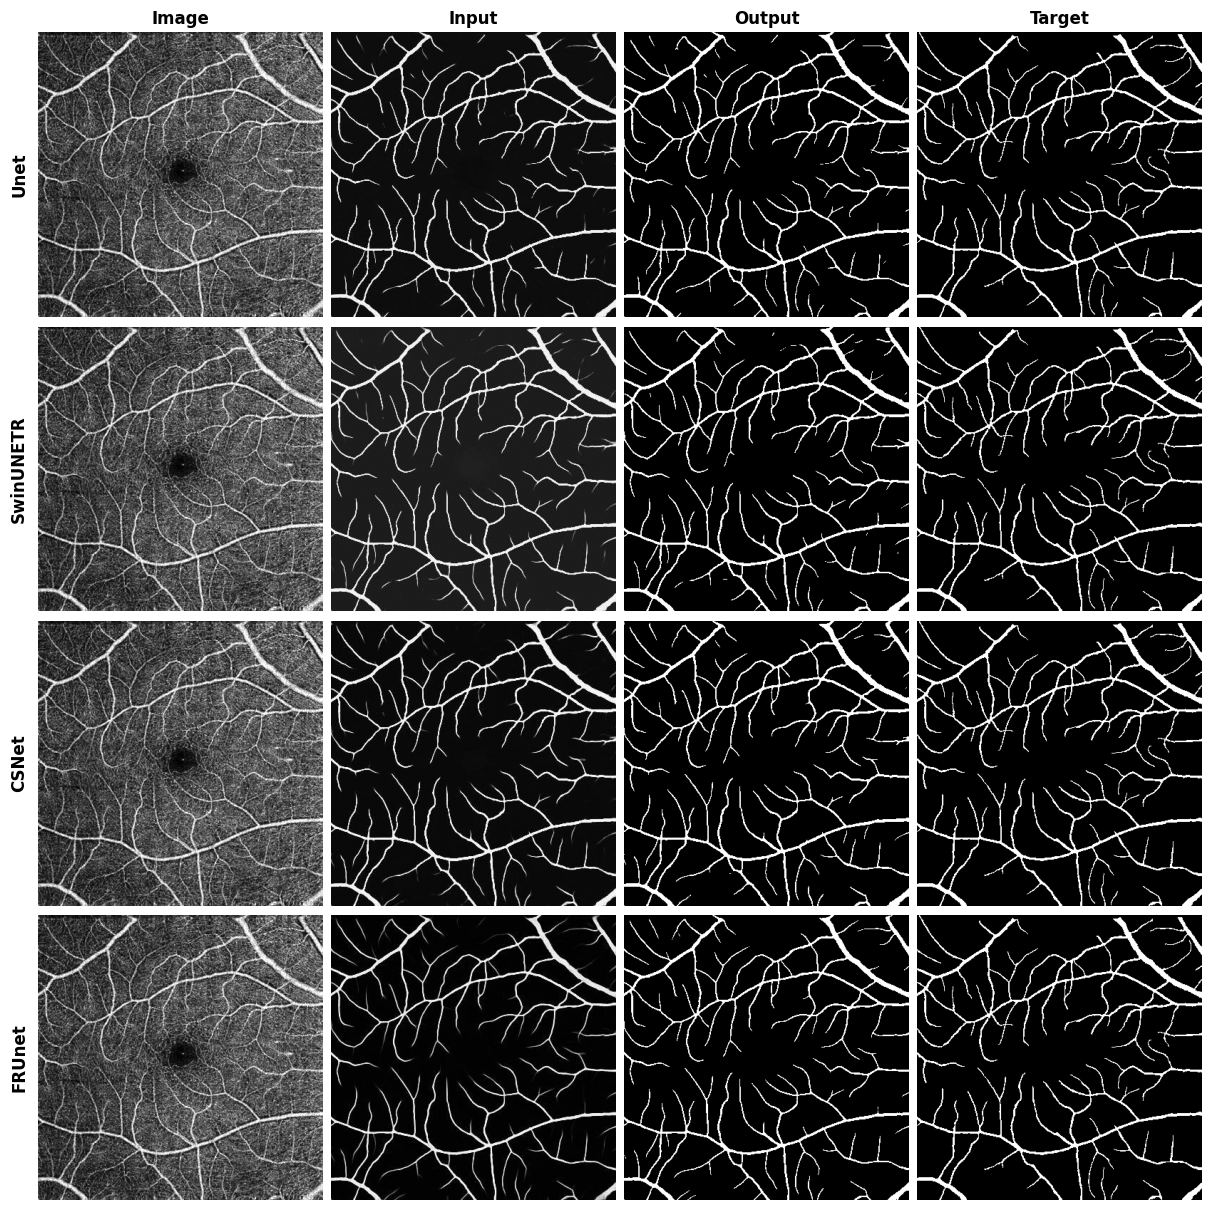

In [21]:
def plot_results(dataset: str, sampling_method: str = "", models: List[str] = DEFAULT_MODELS, index: int = 0):
    """Generate comparison plots."""
    model_images = {}

    # 이미지 검색 로직 최적화
    for model in models:
        work_path = _get_workdir_path(dataset, model, sampling_method)
        # 최신 결과 폴더 찾기
        res_dirs = sorted(work_path.glob("results-*"))
        if not res_dirs:
            print(f"No result directories found for {model} in {work_path}")
            continue

        latest_dir = res_dirs[-1]
        print(f"Searching in {latest_dir}")
        images = natsorted(list(latest_dir.glob("*image*")))
        inputs = natsorted(list(latest_dir.glob("*input*")))
        targets = natsorted(list(latest_dir.glob("*target*")))
        outputs = natsorted(list(latest_dir.glob("*final_output*")))

        lengths = [len(images), len(inputs), len(targets), len(outputs)]
        if min(lengths) == 0:
            print(f"Missing files in {latest_dir}")
            continue

        # 안전한 인덱스 선택 (모든 리스트의 최소 길이 기준)
        max_idx = min(lengths) - 1
        safe_idx = min(index, max_idx)

        # 샘플 기준 이미지 경로 매핑
        imgs = {
            "Image": images[safe_idx],
            "Input": inputs[safe_idx],
            "Output": outputs[safe_idx],
            "Target": targets[safe_idx]
        }

        if all(p.exists() for p in imgs.values()):
            model_images[model] = imgs

    if not model_images:
        print(f"No images found for plotting {sampling_method}-{dataset}")
        return

    n_models = len(model_images)
    fig, axes = plt.subplots(n_models, 4, figsize=(12, 3 * n_models), constrained_layout=True)
    if n_models == 1:
        axes = axes[None, :]

    for idx, (model, files) in enumerate(model_images.items()):
        for col, (title, path) in enumerate(files.items()):
            ax = axes[idx, col] if n_models > 1 else axes[0, col]
            if path.suffix == ".npy":
                data = np.load(path)
                data = np.asarray(data, dtype=np.float32)
                data = np.squeeze(data)
                if data.ndim > 2:
                    data = data[..., 0]
                dmin = float(data.min())
                dmax = float(data.max())
                rng = dmax - dmin
                if rng > 0:
                    data = (data - dmin) / rng
                else:
                    data = np.zeros_like(data)
                ax.imshow(data, cmap='gray', vmin=0.0, vmax=1.0)
            else:
                img = Image.open(path).convert("L")  # 흑백 변환 통일
                ax.imshow(img, cmap='gray')
            ax.axis('off')

            if idx == 0:
                ax.set_title(title, fontsize=12, fontweight='bold')
            if col == 0:
                ax.text(-0.1, 0.5, model, transform=ax.transAxes,
                        rotation=90, va='center', fontsize=12, fontweight='bold')

    plt.show()

    plt.close()
%matplotlib inline
# datasets = ["DRIVE", "OCTA500_3M", "OCTA500_6M"]
datasets = ["OCTA500_6M"]
models = DEFAULT_MODELS
# sampling_methods = ["gaussian", "bernoulli", "poisson"]
sampling_methods = ["flow"]

configs = list(itertools.product(sampling_methods, datasets, models))
unique_ds_sm = set((ds, sm) for sm, ds, _ in configs)
for ds, sm in unique_ds_sm:
    plot_results(ds, sm, models)

In [22]:
from natsort import natsorted


def plot_results_separately(dataset: str, sampling_method: str = "", models: List[str] = DEFAULT_MODELS, index: int = 0):
    """Generate comparison plots."""
    model_images = {}

    # 이미지 검색 로직 최적화
    for model in models:
        work_path = _get_workdir_path(dataset, model, sampling_method)
        # 최신 결과 폴더 찾기
        res_dirs = sorted(work_path.glob("results-*"))
        if not res_dirs:
            continue

        latest_dir = res_dirs[-1]
        images = natsorted(list(latest_dir.glob("*image*")))
        inputs = natsorted(list(latest_dir.glob("*input*")))
        targets = natsorted(list(latest_dir.glob("*target*")))
        outputs = natsorted(list(latest_dir.glob("*final_output*")))

        lengths = [len(images), len(inputs), len(targets), len(outputs)]
        if min(lengths) == 0:
            print(f"Missing files in {latest_dir}")
            continue

        max_idx = min(lengths) - 1
        safe_idx = min(index, max_idx)

        # 샘플 기준 이미지 경로 매핑
        imgs = {
            "Image": images[safe_idx],
            "Input": inputs[safe_idx],
            "Output": outputs[safe_idx],
            "Target": targets[safe_idx]
        }

        if all(p.exists() for p in imgs.values()):
            model_images[model] = imgs

    if not model_images:
        print(f"No images found for plotting {sampling_method}-{dataset}")
        return

    os.makedirs(FIGURES_DIR / "separated", exist_ok=True)

    for idx, (model, files) in enumerate(model_images.items()):
        for col, (title, path) in enumerate(files.items()):
            plt.figure(figsize=(3, 3), frameon=False)
            print(model, title)

            if path.suffix == ".npy":
                data = np.load(path)
                data = np.asarray(data, dtype=np.float32)
                data = np.squeeze(data)
                if data.ndim > 2:
                    data = data[..., 0]
                dmin = float(data.min())
                dmax = float(data.max())
                rng = dmax - dmin
                if rng > 0:
                    data = (data - dmin) / rng
                else:
                    data = np.zeros_like(data)
                plt.imshow(data, cmap='gray', vmin=0.0, vmax=1.0)
                plt.axis('off')
                plt.show()
                plt.imsave(FIGURES_DIR / "separated" / f"{dataset}_{model}_{title}.png", data, cmap='gray', vmin=0.0, vmax=1.0)
            else:
                img = Image.open(path).convert("L")
                plt.imshow(img, cmap='gray')
                plt.axis('off')
                plt.show()
                plt.imsave(FIGURES_DIR / "separated" / f"{dataset}_{model}_{title}.png", np.array(img), cmap='gray')

    plt.close()

In [23]:
#  plot image, input, output, target separtely for frunet model
for ds in datasets:
    plot_results_separately(ds, "poisson_flow", ["FRUnet"], index=0)

No images found for plotting poisson_flow-OCTA500_6M


## Metrics

## Comparison of several models

In [26]:
import autorootcwd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from src.utils.evaluate import calculate_metrics
from pathlib import Path
from natsort import natsorted
epoch = 100000

images = []
inputs = []
targets = []
outputs = []
gaussian_outputs = []
binomial_outputs = []

result_dir = Path(f"workdir/flow/OCTA500_6M-FRUnet/results-{epoch:06d}")
# gaussian_dir = Path(f"workdir/gaussian/OCTA500_6M-FRUnet/results-{epoch:06d}")
# binomial_dir = Path(f"workdir/binomial/OCTA500_6M-FRUnet/results-{epoch:06d}")

# 모든 매칭되는 파일 추가
images = natsorted(result_dir.glob("*_image.npy"))
inputs = natsorted(result_dir.glob("*_input.npy"))
targets = natsorted(result_dir.glob("*_target.npy"))
outputs = natsorted(result_dir.glob("*_final_output.npy"))
print(len(images), len(inputs), len(targets), len(outputs))
# gaussian_outputs = natsorted(gaussian_dir.glob("*_final_output.npy"))
# binomial_outputs = natsorted(binomial_dir.glob("*_final_output.npy"))

100 100 100 100


(400, 400) (400, 400) (400, 400) (400, 400)
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
(400, 400) (400, 400) (400, 400) (400, 400)
Fixed FP : 0.00% 0 pixels
Fixed FN : 29.04% 410 pixels
Modified TP : 0.00% 0 pixels
Modified TN : 0.40% 574 pixels


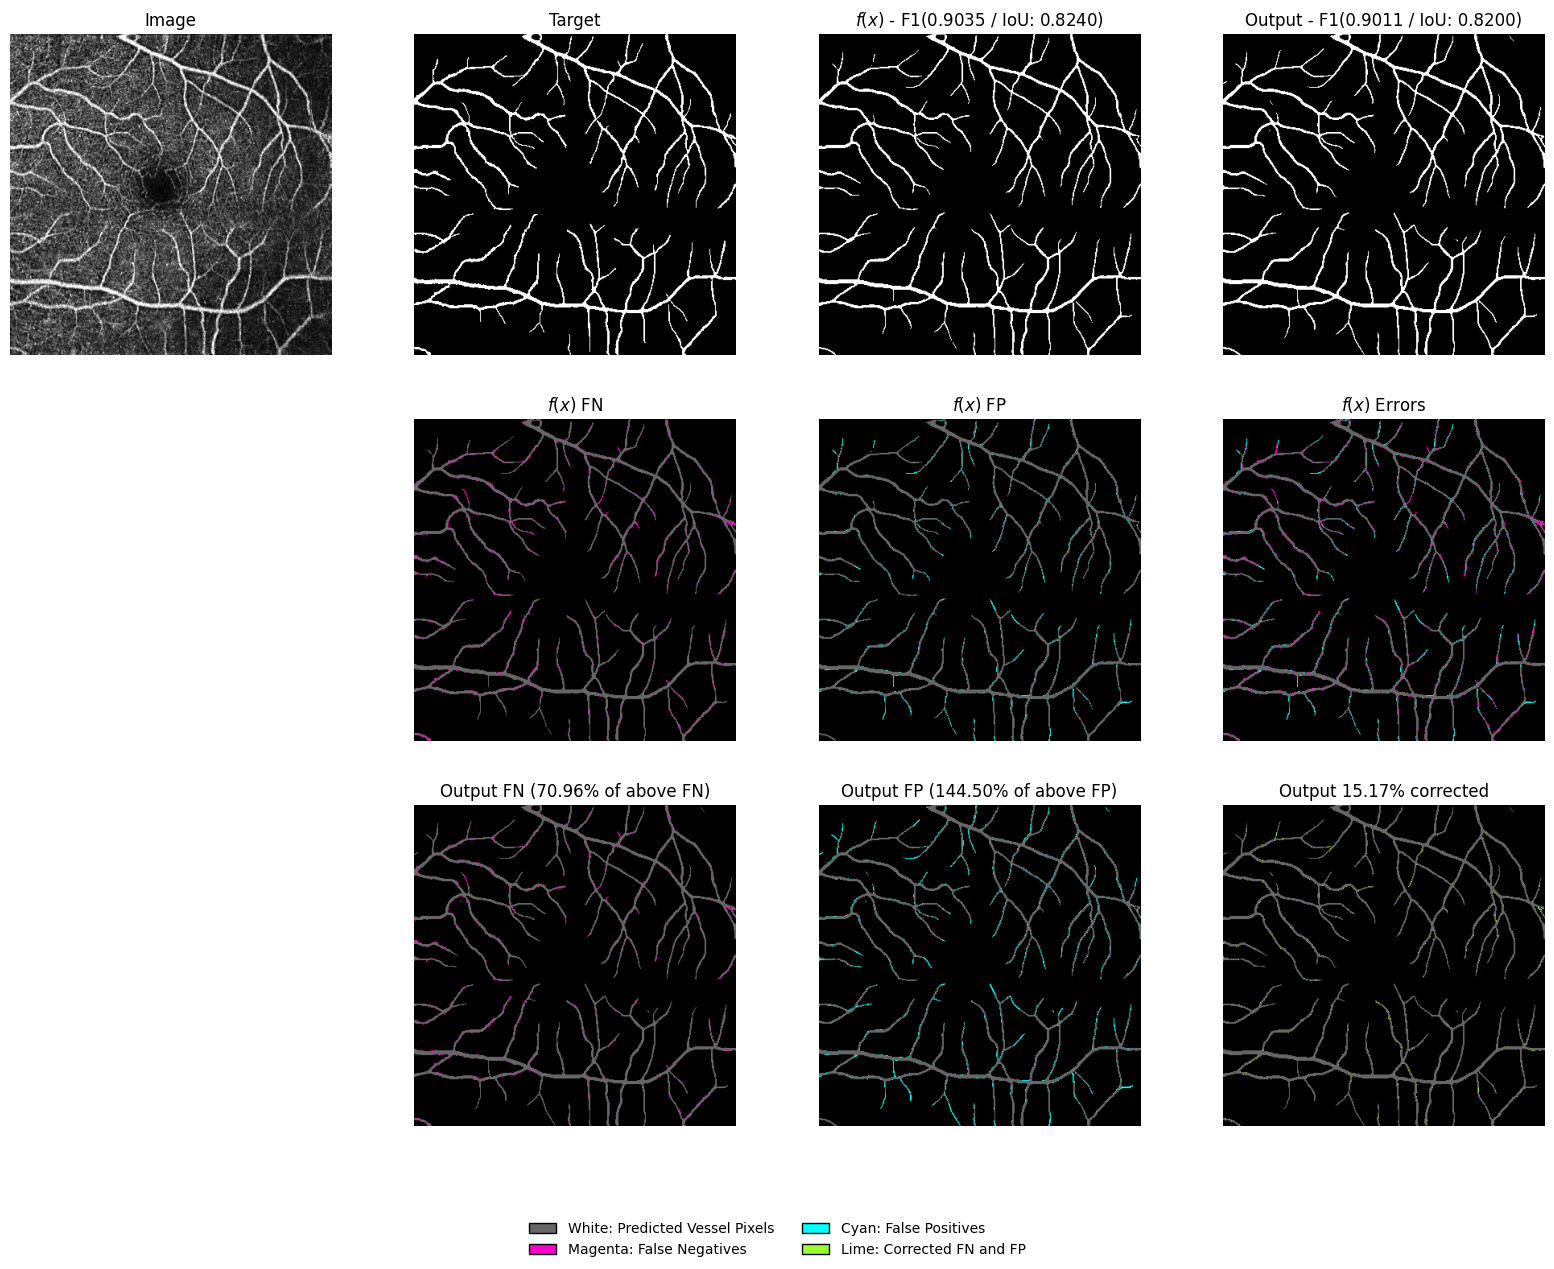

Input Metrics:
f1: 0.9035	| iou: 0.8240	| precision: 0.9075	| recall: 0.8996	| boundary_ap: 0.9407	| boundary_acc: 0.9874	| hd95: 1.0000	| betti_0_error: 15.0000	| betti_1_error: 0.0000	| 
f1: 0.9011	| iou: 0.8200	| precision: 0.8751	| recall: 0.9287	| boundary_ap: 0.9248	| boundary_acc: 0.9922	| hd95: 1.0000	| betti_0_error: 0.0000	| betti_1_error: 5.0000	| 
(400, 400) (400, 400) (400, 400) (400, 400)
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
(400, 400) (400, 400) (400, 400) (400, 400)
Fixed FP : 0.00% 0 pixels
Fixed FN : 19.65% 783 pixels
Modified TP : 0.00% 0 pixels
Modified TN : 0.58% 843 pixels


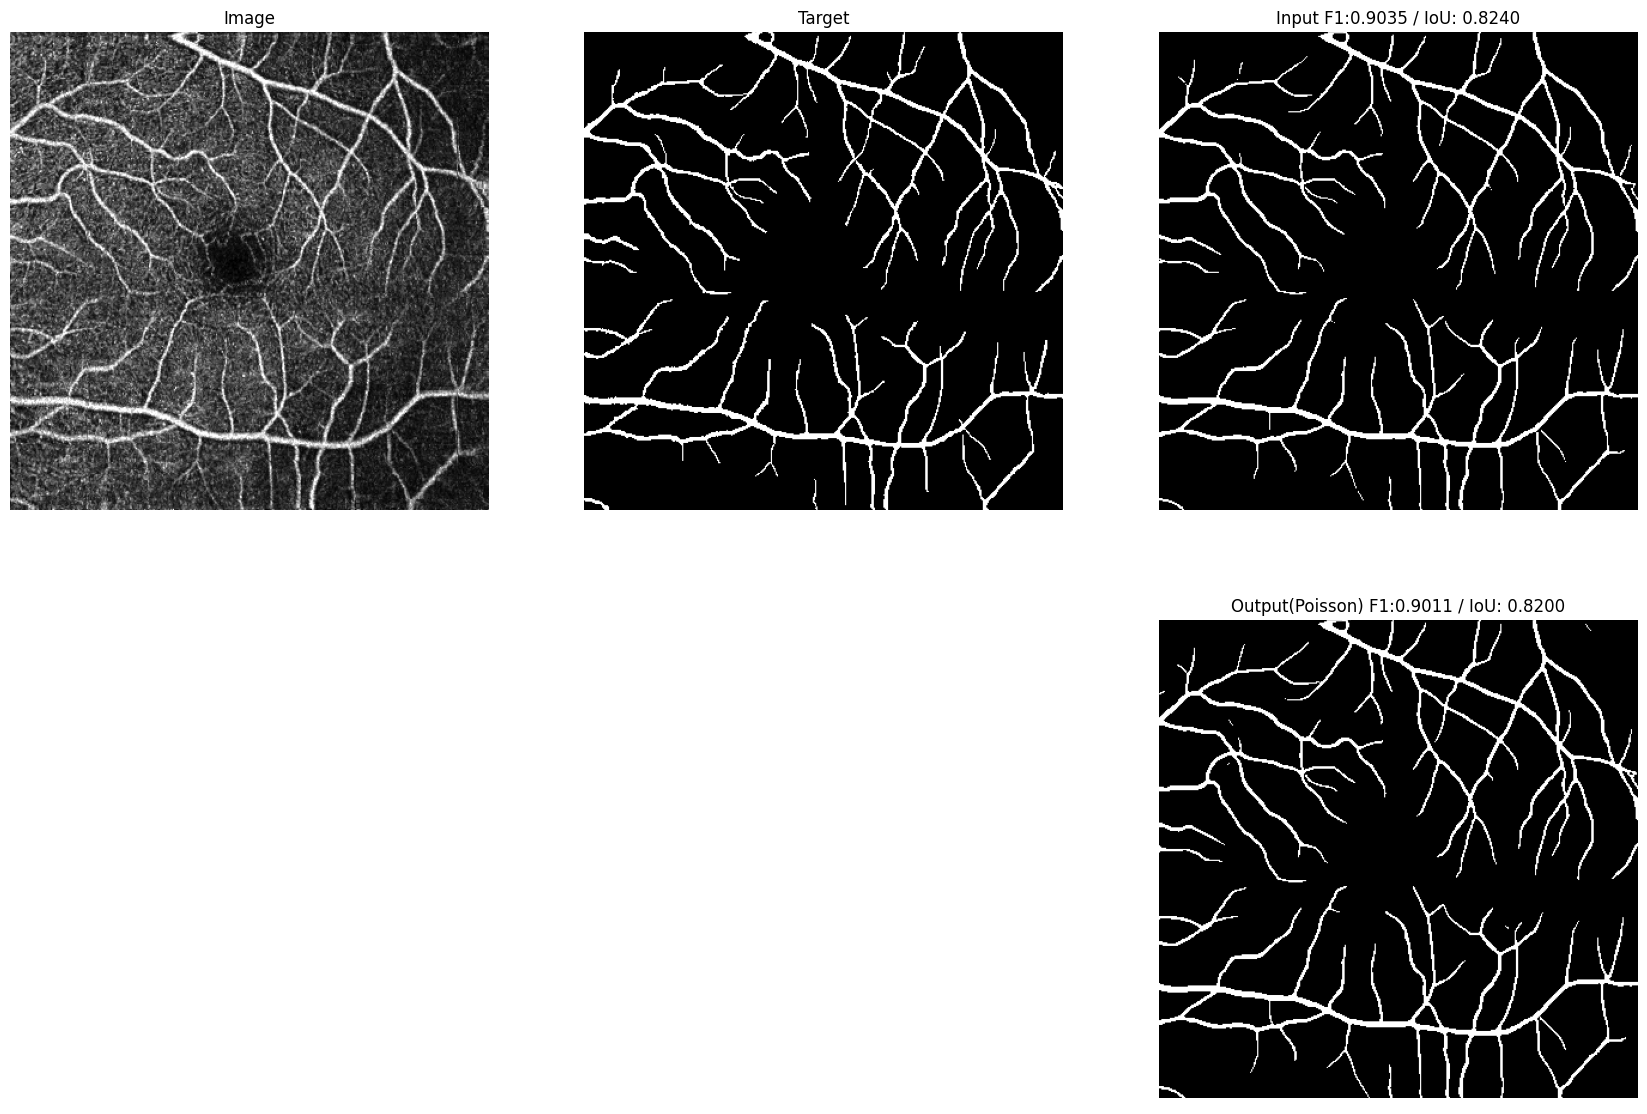

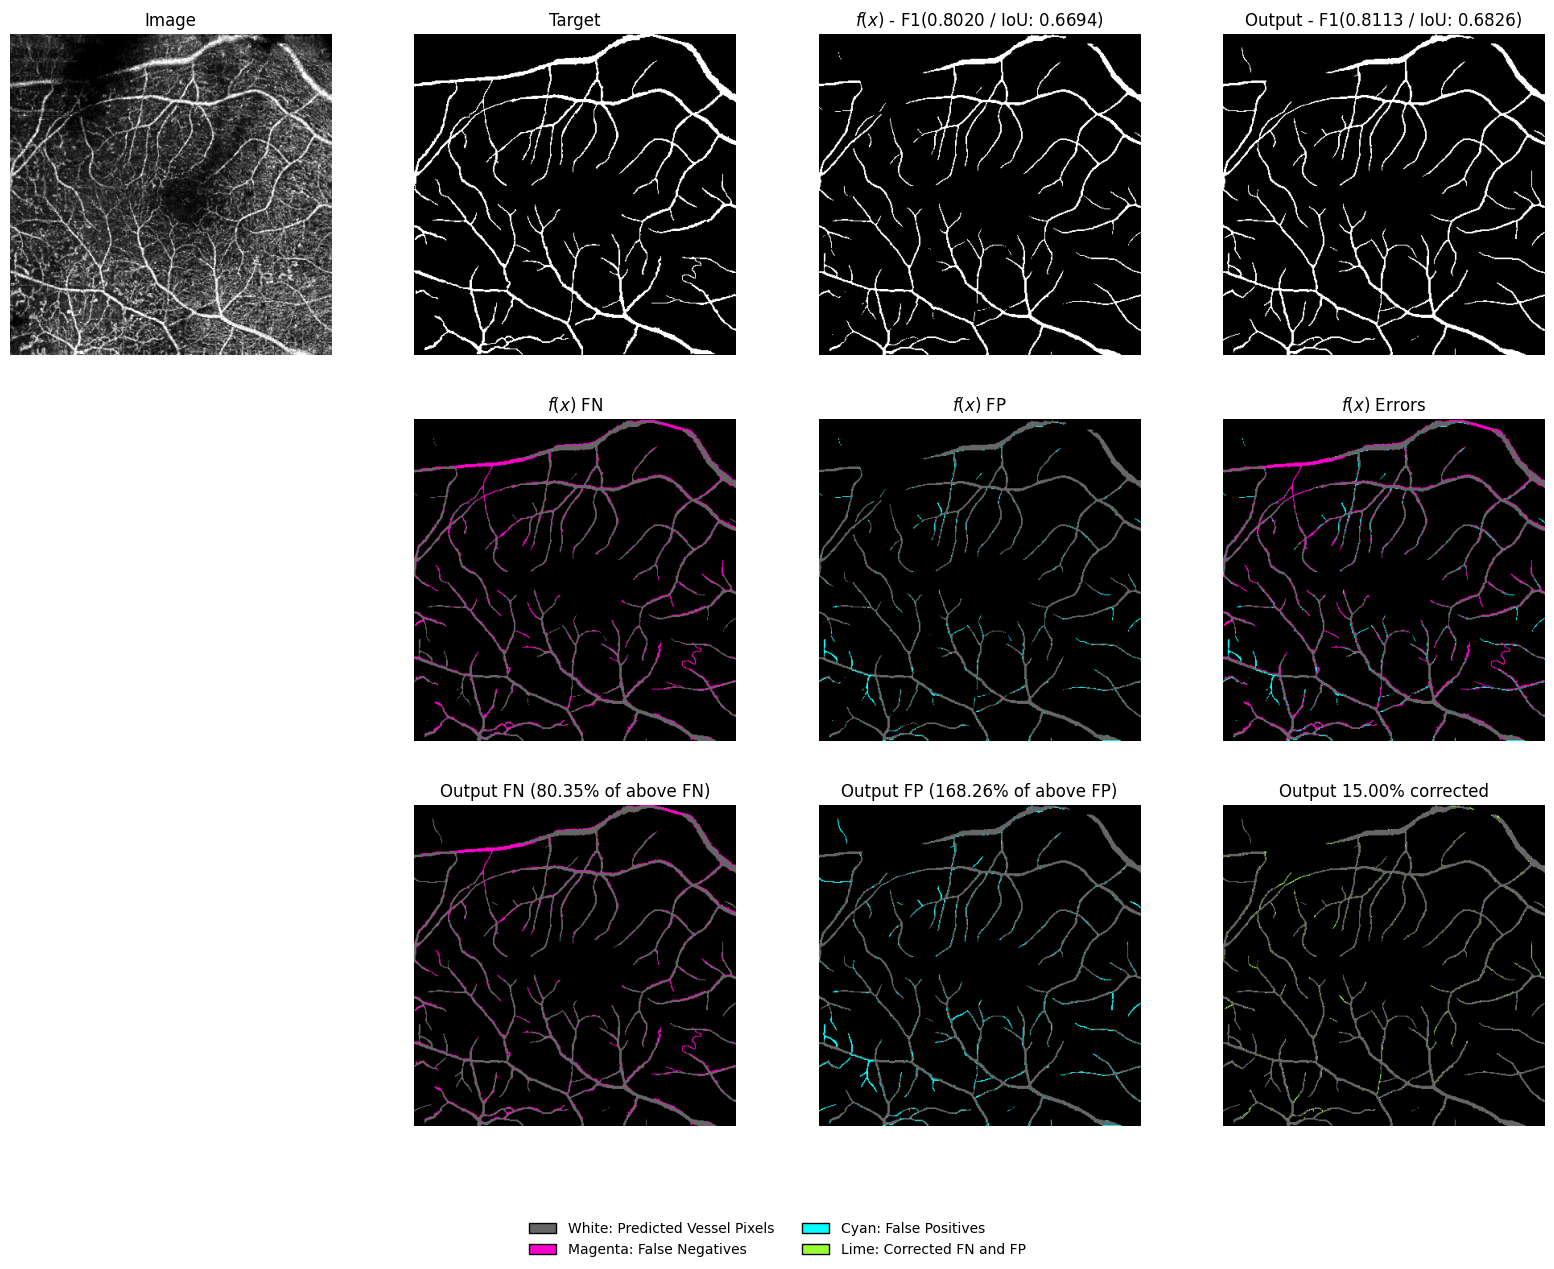

Input Metrics:
f1: 0.8020	| iou: 0.6694	| precision: 0.8954	| recall: 0.7262	| boundary_ap: 0.9021	| boundary_acc: 0.8843	| hd95: 2.2361	| betti_0_error: 133.0000	| betti_1_error: 1.0000	| 
f1: 0.8113	| iou: 0.6826	| precision: 0.8453	| recall: 0.7800	| boundary_ap: 0.8733	| boundary_acc: 0.9181	| hd95: 2.8284	| betti_0_error: 12.0000	| betti_1_error: 0.0000	| 
(400, 400) (400, 400) (400, 400) (400, 400)
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
0.0 1.0 [0. 1.]
(400, 400) (400, 400) (400, 400) (400, 400)
Fixed FP : 0.00% 0 pixels
Fixed FN : 22.56% 1285 pixels
Modified TP : 0.00% 0 pixels
Modified TN : 1.27% 1738 pixels


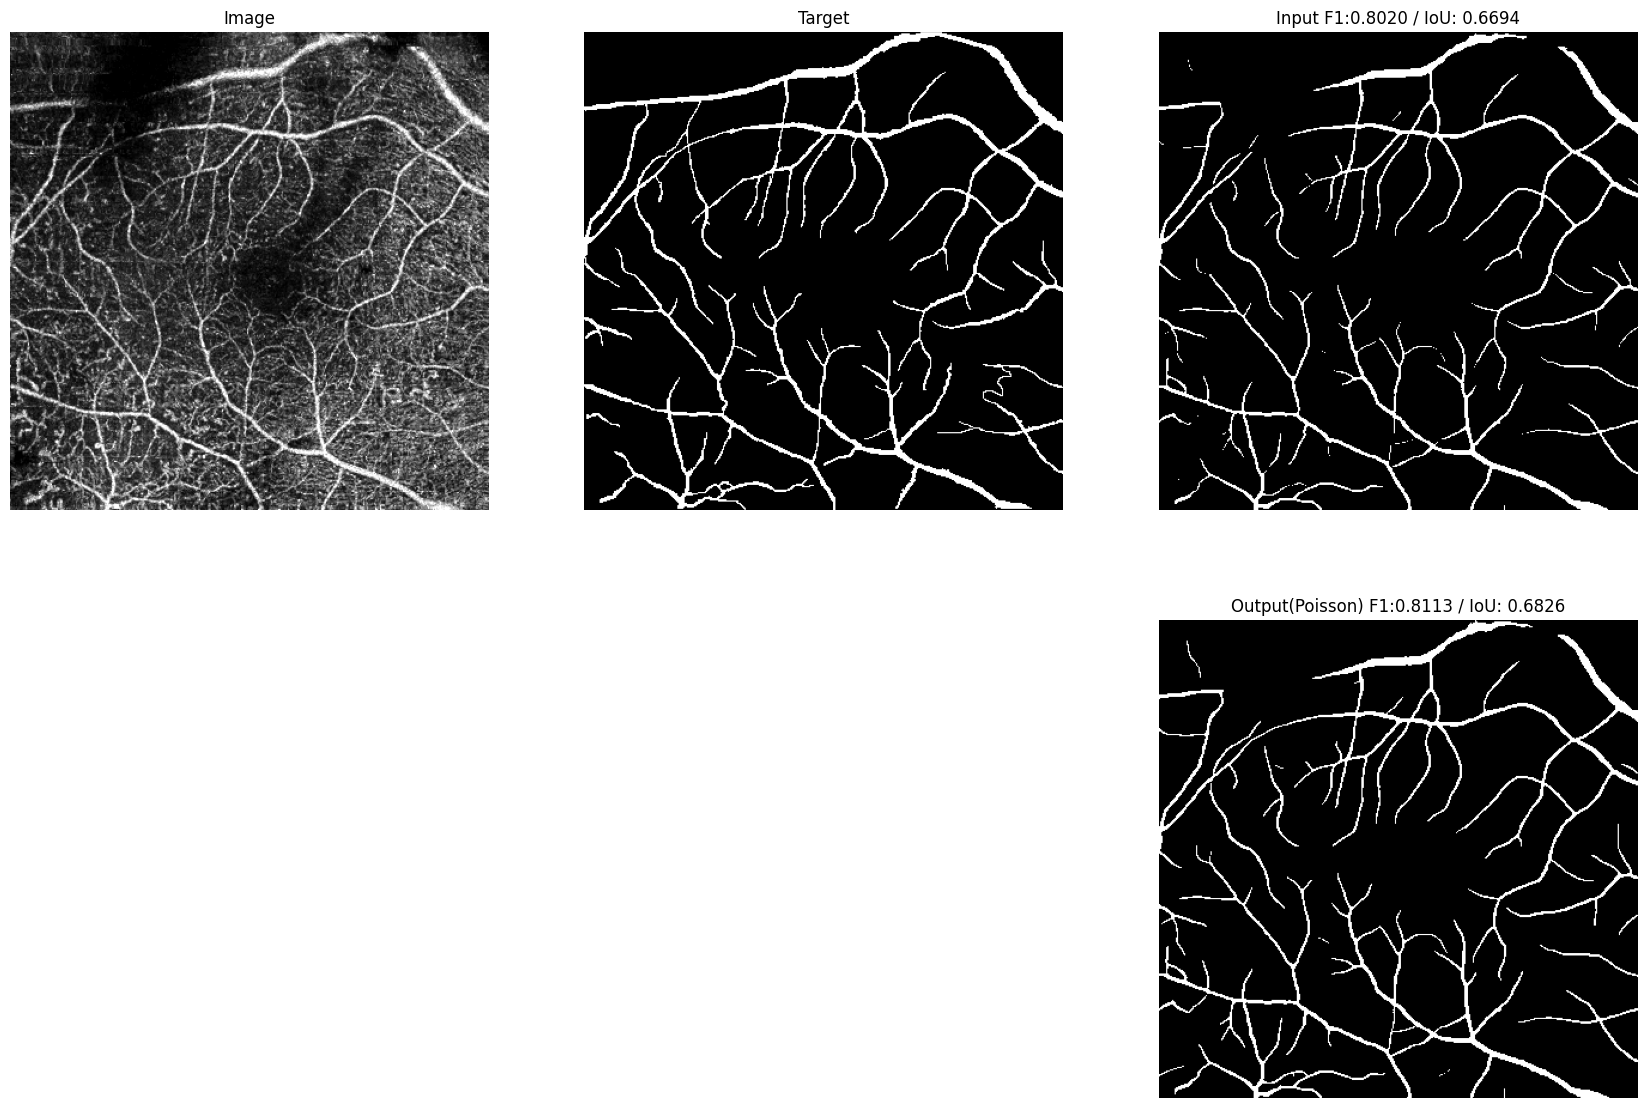

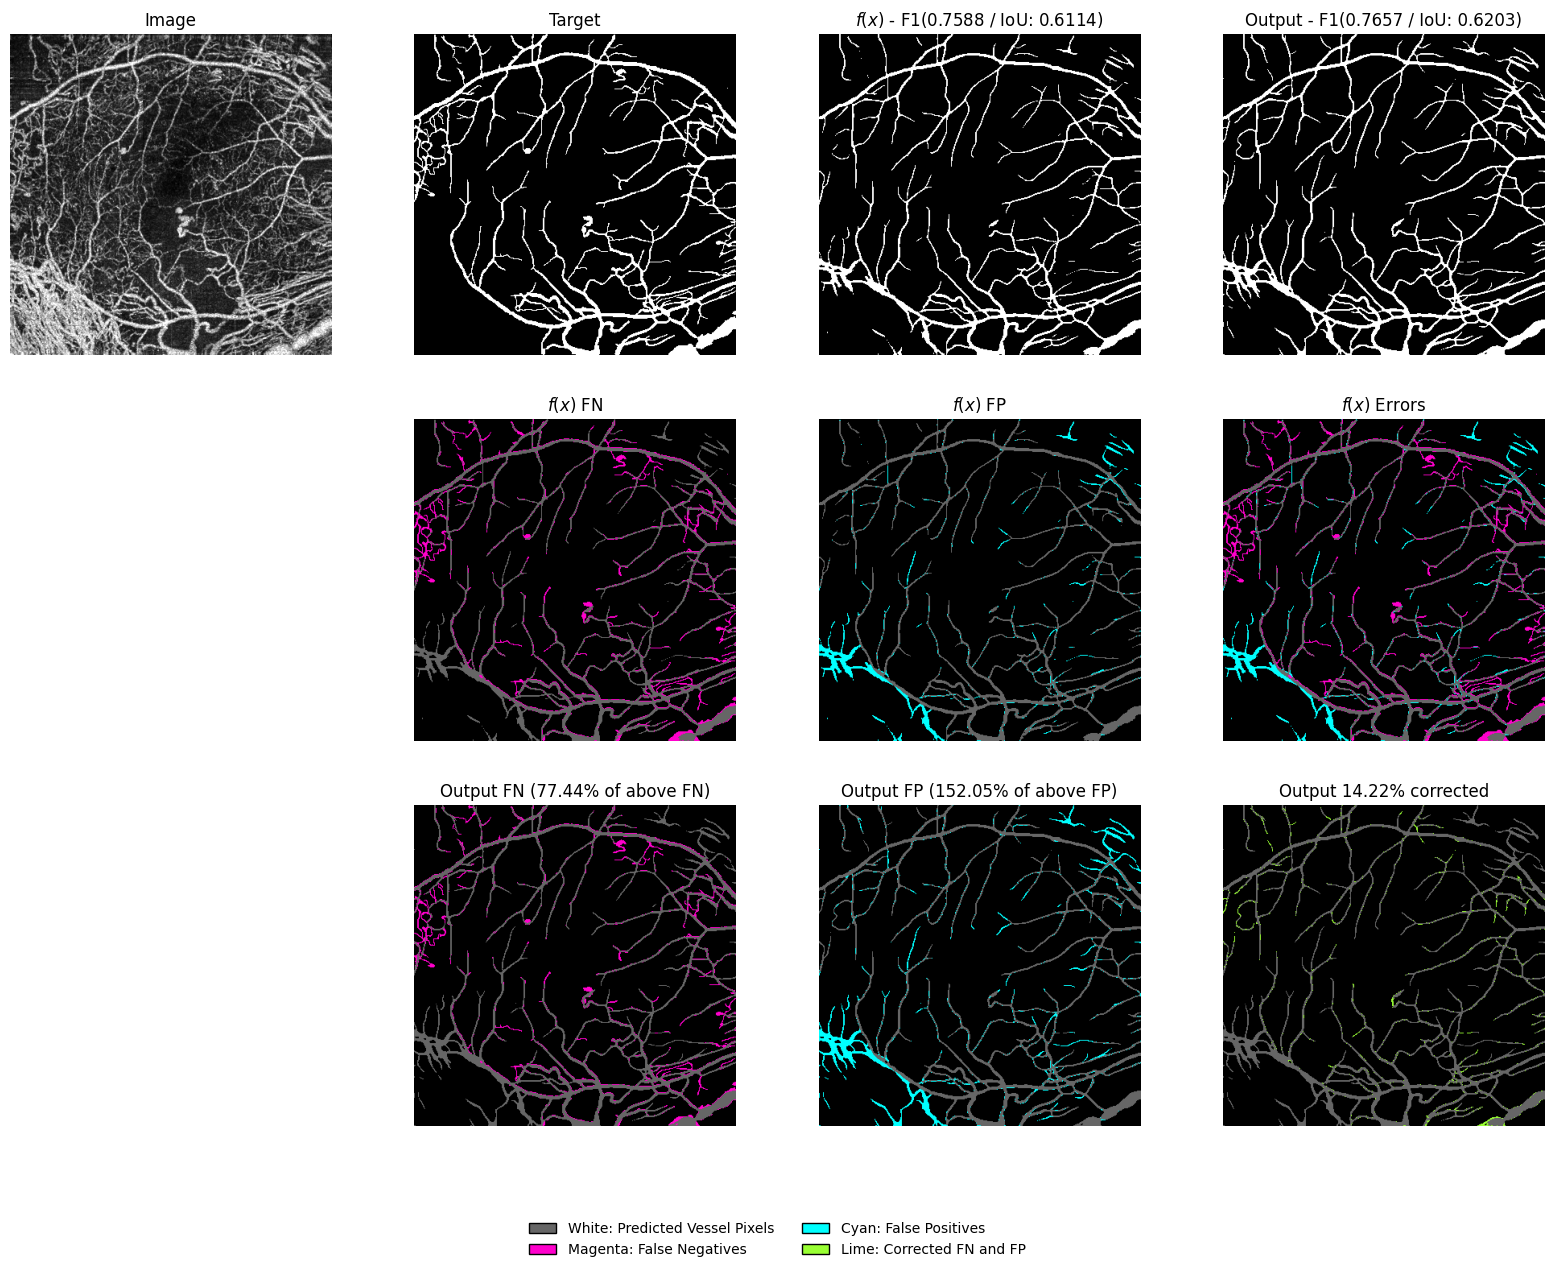

Input Metrics:
f1: 0.7588	| iou: 0.6114	| precision: 0.8098	| recall: 0.7139	| boundary_ap: 0.8310	| boundary_acc: 0.8304	| hd95: 11.0000	| betti_0_error: 100.0000	| betti_1_error: 11.0000	| 
f1: 0.7657	| iou: 0.6203	| precision: 0.7533	| recall: 0.7784	| boundary_ap: 0.7946	| boundary_acc: 0.8648	| hd95: 15.8114	| betti_0_error: 28.0000	| betti_1_error: 12.0000	| 


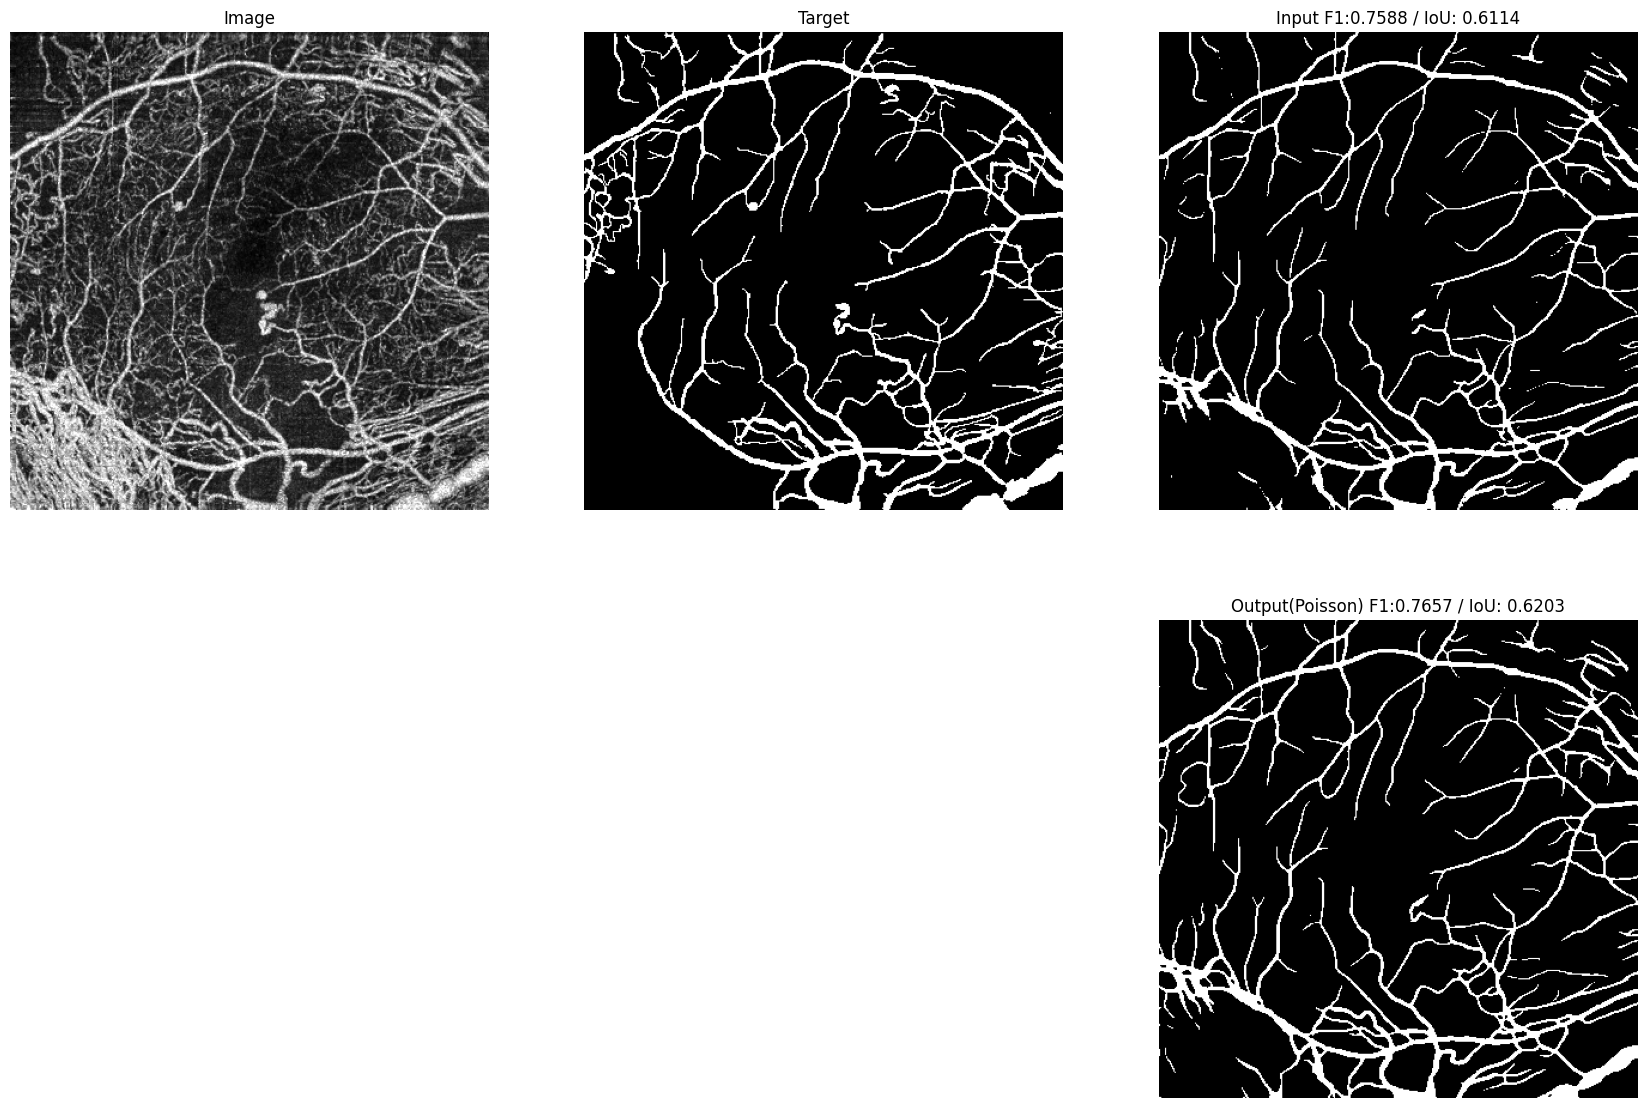

In [ ]:
%matplotlib inline
from matplotlib.patches import Patch
indexes = [24, 96, 99]
# Process each output array separately
for idx in indexes:
    output_arr = np.load(outputs[idx])[..., 0]
    image_arr = np.load(images[idx])[0]
    input_arr = np.load(inputs[idx])[0]
    target_arr = np.load(targets[idx])[0]
    
    # gaussian_output_arr = np.load(gaussian_outputs[idx])[..., 0]
    # binomial_output_arr = np.load(binomial_outputs[idx])[..., 0]
    print(image_arr.shape, input_arr.shape, output_arr.shape, target_arr.shape)
    # print(gaussian_output_arr.shape, binomial_output_arr.shape)
    

    target_arr = (target_arr - target_arr.min()) / (target_arr.max() - target_arr.min())
    input_arr = (input_arr - input_arr.min()) / (input_arr.max() - input_arr.min())
    input_arr = (input_arr >= 0.5).astype(np.float32)
    output_arr = (output_arr - output_arr.min()) / (output_arr.max() - output_arr.min())
    output_arr = (output_arr >= 0.5).astype(np.float32)
    poisson_output_arr = (output_arr - output_arr.min()) / (output_arr.max() - output_arr.min())
    poisson_output_arr = (output_arr >= 0.5).astype(np.float32)
    # gaussian_output_arr = (gaussian_output_arr - gaussian_output_arr.min()) / (gaussian_output_arr.max() - gaussian_output_arr.min())
    # gaussian_output_arr = (gaussian_output_arr >= 0.5).astype(np.float32)
    # binomial_output_arr = (binomial_output_arr - binomial_output_arr.min()) / (binomial_output_arr.max() - binomial_output_arr.min())
    #   binomial_output_arr = (binomial_output_arr >= 0.5).astype(np.float32)

    print(target_arr.min(), target_arr.max(), np.unique(target_arr))
    print(input_arr.min(), input_arr.max(), np.unique(input_arr))
    print(output_arr.min(), output_arr.max(), np.unique(output_arr))

    input_metrics = calculate_metrics(pred=input_arr, label=target_arr)
    output_metrics = calculate_metrics(pred=output_arr, label=target_arr)
    # gaussian_metrics = calculate_metrics(pred=gaussian_output_arr, label=target_arr)
    # binomial_metrics = calculate_metrics(pred=binomial_output_arr, label=target_arr)
    print(target_arr.shape, input_arr.shape, output_arr.shape, image_arr.shape)
    
    # Boolean masks for class membership
    target_mask = target_arr > 0
    input_mask = input_arr > 0
    output_mask = output_arr > 0

    # Error masks
    input_fp = np.logical_and(~target_mask, input_mask)
    input_fn = np.logical_and(target_mask, ~input_mask)
    output_fp = np.logical_and(~target_mask, output_mask)
    output_fn = np.logical_and(target_mask, ~output_mask)
    
    input_tp = np.logical_and(target_mask, input_mask)
    input_tn = np.logical_and(~target_mask, ~input_mask)

    # Pixels that were wrong in the input but fixed in the output
    corrected_fp = np.logical_and(input_fp, ~output_mask)
    corrected_fn = np.logical_and(input_fn, output_mask)
    input_to_output_fixed = np.logical_or(corrected_fp, corrected_fn)

    mispredicted_tp = np.logical_and(input_tp, ~output_mask)
    mispredicted_tn = np.logical_and(input_tn, output_mask)

    print(f"Fixed FP : {np.sum(corrected_fp) / np.sum(input_fp):.2%} {np.sum(corrected_fp)} pixels")
    print(f"Fixed FN : {np.sum(corrected_fn) / np.sum(input_fn):.2%} {np.sum(corrected_fn)} pixels")
    print(f"Modified TP : {np.sum(mispredicted_tp) / np.sum(input_tp):.2%} {np.sum(mispredicted_tp)} pixels")
    print(f"Modified TN : {np.sum(mispredicted_tn) / np.sum(input_tn):.2%} {np.sum(mispredicted_tn)} pixels")

    # Build RGB canvases with fluorescent colors
    input_canvas = np.zeros((*input_arr.shape, 3), dtype=np.float32)
    inputfn_canvas = np.zeros((*input_arr.shape, 3), dtype=np.float32)
    inputfp_canvas = np.zeros((*input_arr.shape, 3), dtype=np.float32)
    outputfn_canvas = np.zeros((*output_arr.shape, 3), dtype=np.float32)
    outputfp_canvas = np.zeros((*output_arr.shape, 3), dtype=np.float32)
    output_corrected_canvas = np.zeros((*output_arr.shape, 3), dtype=np.float32)

    input_canvas[input_mask] = [0.4,0.4,0.4]
    inputfn_canvas[input_mask] = [0.4,0.4,0.4]
    inputfp_canvas[input_mask] = [0.4,0.4,0.4]
    outputfn_canvas[output_mask] = [0.4,0.4,0.4]
    outputfp_canvas[output_mask] = [0.4,0.4,0.4]
    output_corrected_canvas[output_mask] = [0.4,0.4,0.4]

    neon_magenta = np.array([1.0, 0.0, 0.8], dtype=np.float32)
    neon_cyan = np.array([0.0, 1.0, 1.0], dtype=np.float32)
    neon_lime = np.array([0.6, 1.0, 0.2], dtype=np.float32)

    input_canvas[input_fn] = neon_magenta
    input_canvas[input_fp] = neon_cyan
    inputfn_canvas[input_fn] = neon_magenta
    inputfp_canvas[input_fp] = neon_cyan
    outputfn_canvas[output_fn] = neon_magenta
    outputfp_canvas[output_fp] = neon_cyan
    output_corrected_canvas[input_to_output_fixed] = neon_lime

    fig = plt.figure(figsize=(20, 14))
    plt.subplot(3, 4, 1)
    plt.title("Image")
    plt.imshow(image_arr, cmap='gray')
    plt.axis('off')
    plt.subplot(3, 4, 2)
    plt.title("Target")
    plt.imshow(target_arr, cmap='gray')
    plt.axis('off')
    plt.subplot(3, 4, 3)
    plt.title(f"$f(x)$ - F1({input_metrics['f1']:.4f} / IoU: {input_metrics['iou']:.4f})")
    plt.imshow(input_arr, cmap='gray')
    plt.axis('off')
    plt.subplot(3, 4, 4)
    plt.title(f"Output - F1({output_metrics['f1']:.4f} / IoU: {output_metrics['iou']:.4f})")
    plt.imshow(output_arr, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 4, 12)
    plt.title(f"Output {np.sum(input_to_output_fixed) / np.sum(input_fp | input_fn):.2%} corrected")
    plt.imshow(output_corrected_canvas)
    plt.axis('off')
    
    plt.subplot(3, 4, 8)
    plt.title("$f(x)$ Errors")
    plt.imshow(input_canvas)
    plt.axis('off')
    plt.subplot(3, 4, 6)
    plt.title("$f(x)$ FN")
    plt.imshow(inputfn_canvas)
    plt.axis('off')
    plt.subplot(3, 4, 7)
    plt.title("$f(x)$ FP")
    plt.imshow(inputfp_canvas)
    plt.axis('off')
    plt.subplot(3, 4, 10)
    plt.title(f"Output FN ({np.sum(output_fn) / np.sum(input_fn):.2%} of above FN)")
    plt.imshow(outputfn_canvas)
    plt.axis('off')
    plt.subplot(3, 4, 11)
    plt.title(f"Output FP ({np.sum(output_fp) / np.sum(input_fp):.2%} of above FP)")
    plt.imshow(outputfp_canvas)
    plt.axis('off')
    
    
    fig.subplots_adjust(bottom=0.1)
    legend_handles = [
        Patch(facecolor=[0.4,0.4,0.4], edgecolor='black', label='White: Predicted Vessel Pixels'),
        Patch(facecolor=neon_magenta, edgecolor='black', label='Magenta: False Negatives'),
        Patch(facecolor=neon_cyan, edgecolor='black', label='Cyan: False Positives'),
        Patch(facecolor=neon_lime, edgecolor='black', label=f'Lime: Corrected FN and FP'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)
    plt.show()
    
    plt.figure(figsize=(21, 14))
    plt.subplot(2,3,1)
    plt.title("Image")
    plt.imshow(image_arr, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,2)
    plt.title("Target")
    plt.imshow(target_arr, cmap='gray')
    plt.axis('off')  
    
    plt.subplot(2,3,3)
    plt.title(f"Input F1:{input_metrics['f1']:.4f} / IoU: {input_metrics['iou']:.4f}")
    plt.imshow(input_arr, cmap='gray')
    plt.axis('off')

    plt.subplot(2,3,4)
    # plt.title(f"Output(Gaussian) F1:{gaussian_metrics['f1']:.4f} / IoU: {gaussian_metrics['iou']:.4f}")
    # plt.imshow(gaussian_output_arr, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,5)
    # plt.title(f"Output(Binomial) F1:{binomial_metrics['f1']:.4f} / IoU: {binomial_metrics['iou']:.4f}")
    # plt.imshow(binomial_output_arr, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,6)
    plt.title(f"Output(Poisson) F1:{output_metrics['f1']:.4f} / IoU: {output_metrics['iou']:.4f}")
    plt.imshow(output_arr, cmap='gray')
    plt.axis('off')
    

    print("Input Metrics:")
    metrics = calculate_metrics(pred=input_arr, label=target_arr)
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}", end='\t| ')
    print()
    metrics = calculate_metrics(pred=output_arr, label=target_arr)
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}", end='\t| ')
    print()
